In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WP = Path.cwd()  # run the notebook from inside Wpower/
turbines = pd.read_csv(WP / "turbines.csv")
farms    = pd.read_csv(WP / "farms.csv")
power    = pd.read_csv(WP / "power_obs.csv", index_col=0, parse_dates=True)

REG_COLOR = {"BE": "#1f77b4", "UK": "#d62728"}
print(f"{len(turbines)} turbines, {len(farms)} farms, "
      f"power {power.shape[0]} rows x {power.shape[1]} farms")


2380 turbines, 31 farms, power 16312 rows x 31 farms


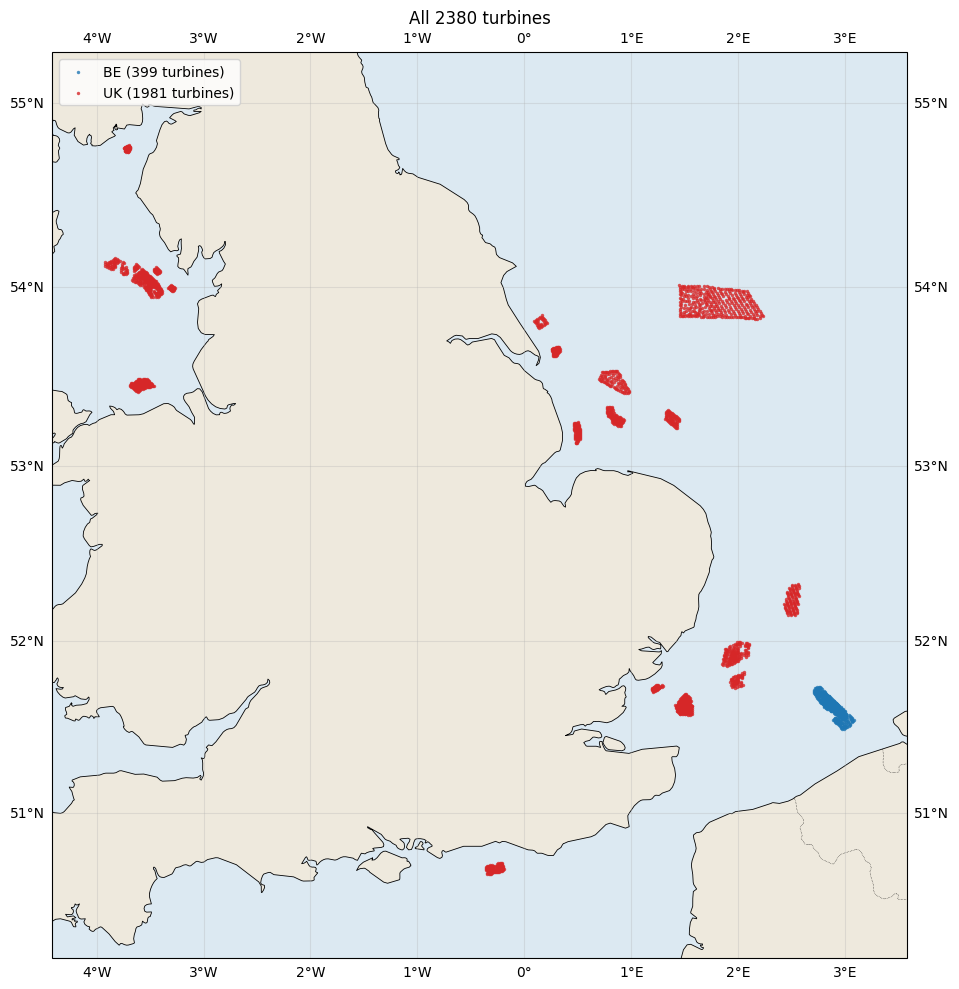

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

DATA = ccrs.PlateCarree()   # our coordinates are lon/lat
pad = 0.5
ext = [turbines.longitude.min() - pad, turbines.longitude.max() + pad,
       turbines.latitude.min()  - pad, turbines.latitude.max()  + pad]

fig = plt.figure(figsize=(11, 10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(ext, crs=DATA)
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#eee9dd")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#dce9f2")
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), lw=0.4, ls=":")
ax.gridlines(draw_labels=True, alpha=0.3)

for reg, g in turbines.groupby("region"):
    ax.scatter(g.longitude, g.latitude, s=6, c=REG_COLOR[reg], transform=DATA,
               label=f"{reg} ({len(g)} turbines)", alpha=0.8, linewidths=0, zorder=5)
ax.legend(loc="upper left")
ax.set_title(f"All {len(turbines)} turbines")
plt.tight_layout(); plt.show()



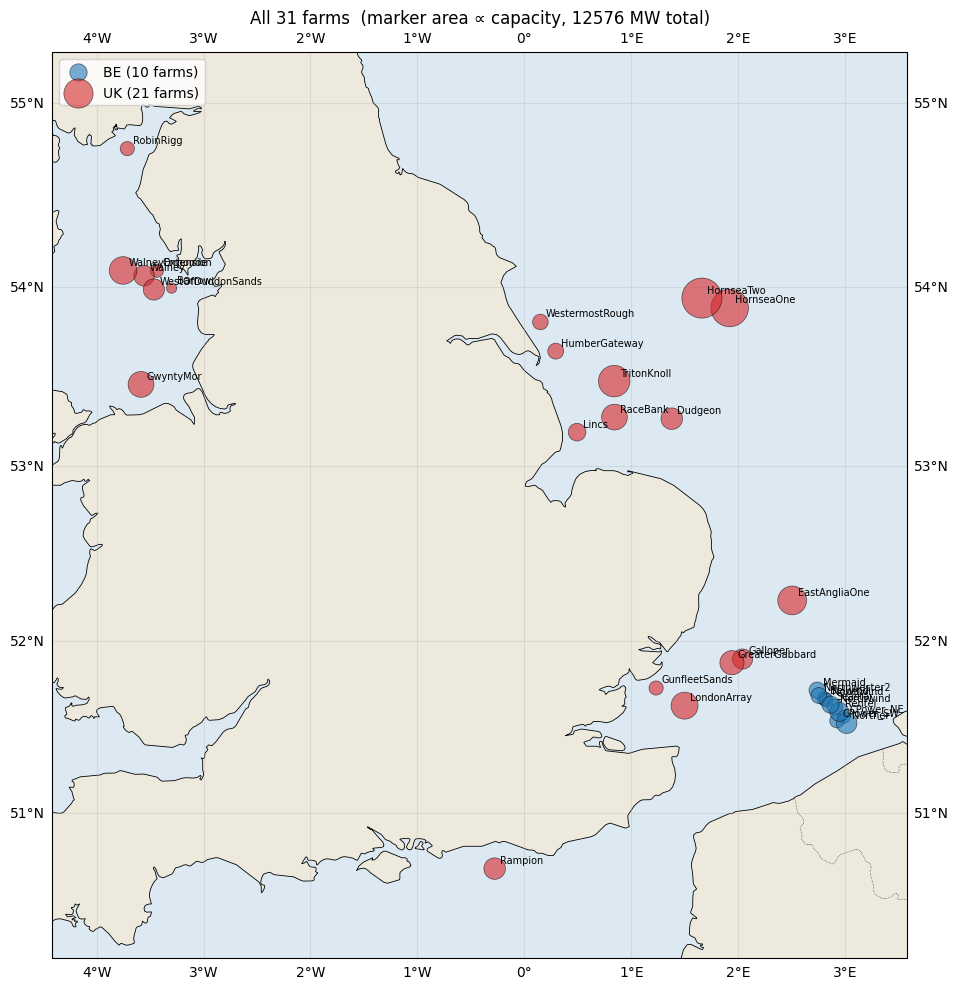

In [3]:
cen = (turbines.groupby("farm")
       .agg(lon=("longitude", "mean"), lat=("latitude", "mean"))
       .join(farms.set_index("farm")[["region", "capacity_mw", "n_turbines"]]))

fig = plt.figure(figsize=(11, 10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(ext, crs=DATA)                 # reuse ext from cell 2
ax.add_feature(cfeature.LAND.with_scale("10m"), facecolor="#eee9dd")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#dce9f2")
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("10m"), lw=0.4, ls=":")
ax.gridlines(draw_labels=True, alpha=0.3)

for reg, g in cen.groupby("region"):
    ax.scatter(g.lon, g.lat, s=g.capacity_mw * 0.6, c=REG_COLOR[reg], transform=DATA,
               label=f"{reg} ({len(g)} farms)", alpha=0.6,
               edgecolors="k", linewidths=0.5, zorder=5)
for name, r in cen.iterrows():
    ax.annotate(name, (r.lon, r.lat), transform=DATA, fontsize=7,
                xytext=(4, 4), textcoords="offset points", zorder=6)
ax.legend(loc="upper left")
ax.set_title(f"All {len(cen)} farms  (marker area ∝ capacity, {cen.capacity_mw.sum():.0f} MW total)")
plt.tight_layout(); plt.show()



In [4]:
# --- pick the day -------------------------------------------------------------
DAY = "2020-1-15"           # e.g. "2023-04-15" to hardcode; None = random day with data

days = power.index.normalize().unique()
if DAY is not None:
    day = pd.Timestamp(DAY, tz="UTC")
    if day not in days:
        raise ValueError(f"{DAY} not in data ({days.min().date()} .. {days.max().date()})")
    d = power.loc[power.index.normalize() == day]
    reporting = d.columns[d.notna().any()].tolist()
    if not reporting:
        raise ValueError(f"{DAY} has no reporting farms — pick another date")
else:
    rng = np.random.default_rng()      # seed for reproducibility, e.g. default_rng(0)
    while True:
        day = days[rng.integers(len(days))]
        d = power.loc[power.index.normalize() == day]
        reporting = d.columns[d.notna().any()].tolist()
        if reporting:
            break

# --- print --------------------------------------------------------------------
d = d[reporting].copy()
d.index = d.index.strftime("%H:%M")    # just the time-of-day (UTC)

print(f"{day.date()}  —  {len(reporting)} of {power.shape[1]} farms reporting")
print("power in MW (value = mean over [t, t+3h), UTC)\n")
with pd.option_context("display.max_columns", None, "display.width", 200,
                       "display.float_format", lambda x: f"{x:6.1f}"):
    print(d.T)                         # farms as rows, times as columns

print(f"\nfleet total per timestep (MW):")
print(d.sum(axis=1).round(1).to_string())



2020-01-15  —  22 of 31 farms reporting
power in MW (value = mean over [t, t+3h), UTC)

time               00:00  03:00  06:00  09:00  12:00  15:00  18:00  21:00
Belwind            146.0  145.7  146.0  137.7   51.3   96.7  125.7   93.7
Nobelwind          159.0  159.0  159.0  156.0   70.7  122.3  151.7  134.7
CPower_SW          165.0  164.7  164.3  164.3   60.0   86.3  150.7  121.0
CPower_NE          142.7  137.3  136.3  136.0   47.7   43.3   84.0   65.7
Norther            342.7  335.0  337.0  345.0  169.0  193.7  321.3  293.7
Northwester2        14.0   15.0   16.7   15.7    3.7    9.3   17.3   18.0
Northwind          209.0  209.0  209.0  208.0   86.0  128.0  183.7  139.0
Rentel             303.0  303.0  303.0  303.0  118.0  163.7  260.3  220.7
Dudgeon            243.4  152.5  273.5  287.8  339.8  355.1  363.5  365.2
GreaterGabbard     456.4  459.1  434.8  193.9  174.3  423.3  455.7  421.0
GunfleetSands      153.1  151.5   91.1   30.0   78.9  121.2  148.7  135.9
GwyntyMor          509.8

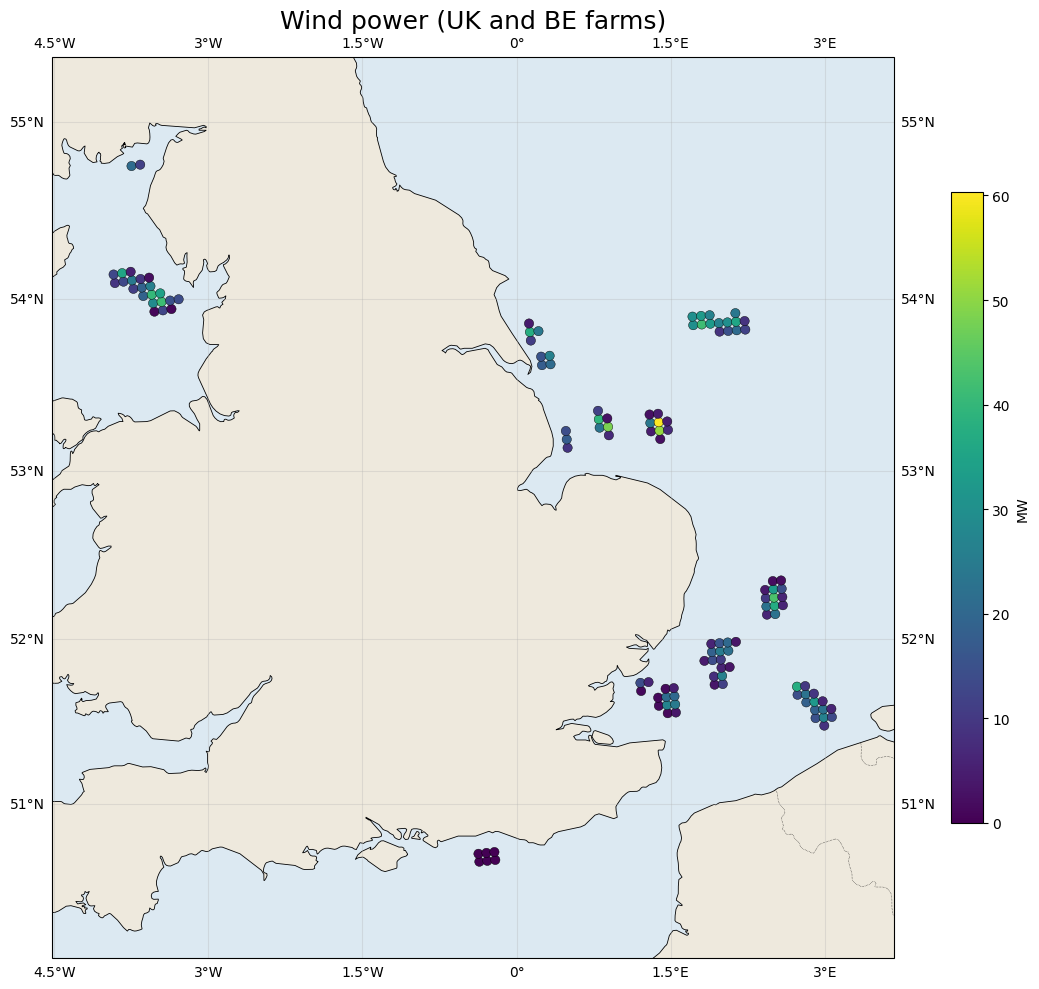

127 cells lit, total 2078 MW


In [5]:
import xarray as xr, numpy as np, pandas as pd, matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

z = xr.open_zarr("power_cerra_src.zarr", consolidated=True)

VAR  = "power"                 # "power" (MW) or "capacityfactor" ([0,1])
DATE = "2021-11-05 12:00"      # hardcode a UTC time, or None for a well-populated one

# --- pick the timestep ---
if DATE is None:
    t = int(np.argmax(np.isfinite(z[VAR]).sum("values").values))
else:
    times = pd.DatetimeIndex(z.time.values)
    t = int(times.get_indexer([pd.Timestamp(DATE)], method="nearest")[0])
when = str(z.time.values[t])[:16]

v = z[VAR].isel(time=t).values
lat, lon = z["latitude"].values, z["longitude"].values
m = np.isfinite(v)

# --- map ---
DATA = ccrs.PlateCarree()
pad = 0.6
ext = [lon[m].min()-pad, lon[m].max()+pad, lat[m].min()-pad, lat[m].max()+pad]

fig = plt.figure(figsize=(12, 10))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent(ext, crs=DATA)
ax.add_feature(cfeature.LAND.with_scale("10m"),  facecolor="#eee9dd")
ax.add_feature(cfeature.OCEAN.with_scale("10m"), facecolor="#dce9f2")
ax.add_feature(cfeature.COASTLINE.with_scale("10m"), lw=0.6)
ax.add_feature(cfeature.BORDERS.with_scale("10m"),   lw=0.4, ls=":")
ax.gridlines(draw_labels=True, alpha=0.3)

sc = ax.scatter(lon[m], lat[m], c=v[m], s=45, cmap="viridis", transform=DATA,
                edgecolors="k", linewidths=0.3, zorder=5,
                vmin=0, vmax=(1.0 if VAR == "capacityfactor" else None))
plt.colorbar(sc, ax=ax, shrink=0.7,
             label="MW" if VAR == "power" else "capacity factor")
ax.set_title(f"Wind power (UK and BE farms)",fontsize=18)
plt.savefig("UKBE.png")
plt.tight_layout(); plt.show()

print(f"{m.sum()} cells lit, total {np.nansum(v):.0f}"
      f"{' MW' if VAR == 'power' else ' (sum of CF)'}")



turbine_specs.csv columns: ['cut_in_ms', 'rated_ws_ms', 'cut_out_ms', 'rated_power_mw', 'rotor_diameter_m'] 
-> using 'rotor_diameter_m' as rotor diameter

        farm  n   cap_MW     nn_m     nn_D  rotor_m  area_km2  dens_MW_km2  axis_deg    align
     Seastar 30   252.00   643.18     3.85   167.00     16.63        15.15    128.44     0.91
   Northwind 72   216.00   437.32     3.90   112.00     13.01        16.60    139.17     0.73
Northwester2 23   218.50   713.33     4.35   164.00     10.01        21.82    168.02     0.30
     Mermaid 28   235.20   753.07     4.51   167.00     15.97        14.73    141.07     0.41
      Rentel 42   308.70   695.25     4.51   154.00     23.49        13.14    132.01     0.90
     Belwind 56   171.00   442.57     4.86    91.07     11.46        14.93    129.64     0.88
     Norther 44   369.60   802.81     4.90   164.00     41.39         8.93    143.97     0.43
   Nobelwind 50   165.00   563.22     5.03   112.00     34.99         4.72    145.78     0.4

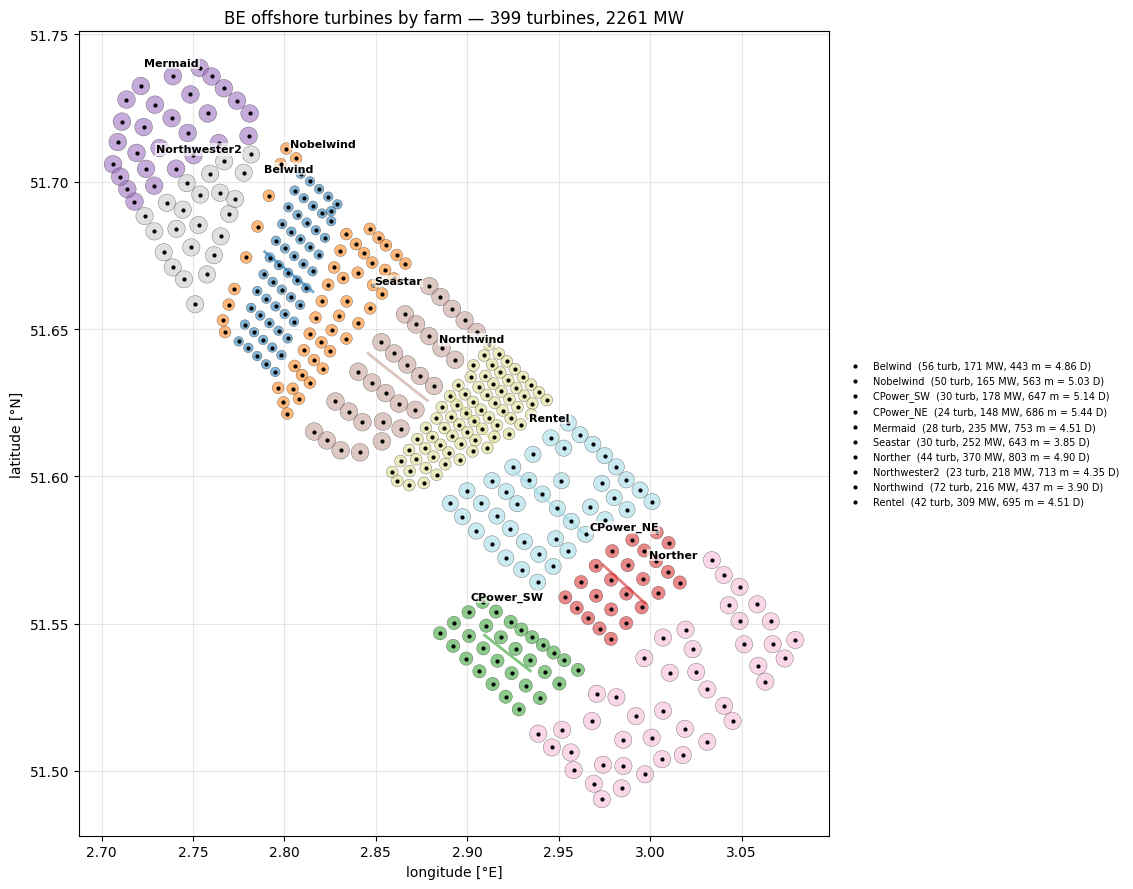

In [14]:
# ── BOZ turbine map, coloured by farm, with per-farm density ───────────────────
from pathlib import Path
import re
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.spatial import cKDTree, ConvexHull

WPOWER_DIR = Path("/mnt/weatherloss/WindPower/data/WPDistr")
REGION     = "BE"        # "BE" | "UK" | "all"
ANNOTATE   = True        # farm names on the map
SHOW_AXIS  = True        # draw each farm's packing axis through its centroid
FLEET_RE = re.compile(r"\s*(\d+)\s*x\s*(.+?)\s*$")   # same regex verify_power.py uses

turb  = pd.read_csv(WPOWER_DIR / "turbines.csv")
farms = pd.read_csv(WPOWER_DIR / "farms.csv")
specs = pd.read_csv(WPOWER_DIR / "turbine_specs.csv", index_col=0)

if REGION != "all":
    keep = farms[farms.region.str.upper() == REGION].farm
    turb, farms = turb[turb.farm.isin(keep)], farms[farms.farm.isin(keep)]
names = farms.farm.tolist()

# rotor diameter, if turbine_specs.csv carries it (column name unknown -> detect)
rot_col = next((c for c in specs.columns if "rotor" in c.lower() or "diam" in c.lower()), None)
print("turbine_specs.csv columns:", list(specs.columns),
      f"\n-> using {rot_col!r} as rotor diameter" if rot_col else "\n-> no rotor column found")

def local_xy(lon, lat):
    """lon/lat -> metres east/north about the farm centroid."""
    e = (lon - lon.mean()) * 111320.0 * np.cos(np.radians(lat.mean()))
    n = (lat - lat.mean()) * 111320.0
    return np.c_[e, n]

rows = []
for f in names:
    t = turb[turb.farm == f]
    p = local_xy(t.longitude.to_numpy(), t.latitude.to_numpy())
    nn = cKDTree(p).query(p, k=2)[0][:, 1]              # distance to nearest other turbine
    v  = p[cKDTree(p).query(p, k=2)[1][:, 1]] - p
    brg = np.degrees(np.arctan2(v[:, 0], v[:, 1])) % 180.0
    a = np.radians(2 * brg); C, S = np.cos(a).mean(), np.sin(a).mean()
    axis, align = (np.degrees(np.arctan2(S, C)) / 2) % 180.0, float(np.hypot(C, S))
    area = ConvexHull(p).volume / 1e6 if len(p) > 2 else np.nan   # 2-D hull "volume" = area
    cap  = float(farms.set_index("farm").loc[f, "capacity_mw"])

    D = np.nan
    if rot_col:                        # fleet is "55x Vestas-3-V90; 1x AlstomHaliade-6-150"
        w = []                         # note: NO space before the 'x' -- hence the regex
        for chunk in str(farms.set_index("farm").loc[f, "fleet"]).split(";"):
            m = FLEET_RE.match(chunk)
            if m and m.group(2) in specs.index:
                w.append((int(m.group(1)), float(specs.loc[m.group(2), rot_col])))
        if w:
            D = sum(c * d for c, d in w) / sum(c for c, _ in w)   # turbine-count-weighted mean

    rows.append(dict(farm=f, n=len(t), cap_MW=cap, nn_m=nn.mean(), nn_D=nn.mean() / D if D else np.nan,
                     rotor_m=D, area_km2=area, dens_MW_km2=cap / area if area else np.nan,
                     axis_deg=axis, align=align))

tbl = pd.DataFrame(rows).sort_values("nn_D" if rot_col else "nn_m")
print("\n" + tbl.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
print("\nnn_D = mean nearest-neighbour spacing in ROTOR DIAMETERS -- the variable wake loss "
      "scales with.\nalign: 1 = turbines in clean rows, 0 = isotropic (then axis_deg means little).")

# ── map ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
cols = plt.cm.tab20(np.linspace(0, 1, len(names)))
for c, f in zip(cols, names):
    t = turb[turb.farm == f]
    r = tbl.set_index("farm").loc[f]
    lab = f"{f}  ({r.n:.0f} turb, {r.cap_MW:.0f} MW, {r.nn_m:.0f} m"
    lab += f" = {r.nn_D:.2f} D)" if rot_col and np.isfinite(r.nn_D) else ")"
    from matplotlib.collections import EllipseCollection
    R = 2.0 * r.rotor_m                       # 2 rotor diameters, in metres
    wx = 2 * R / (111320 * np.cos(np.radians(t.latitude.mean())))   # degrees lon
    wy = 2 * R / 111320                                             # degrees lat
    ax.add_collection(EllipseCollection(
        widths=np.full(len(t), wx), heights=np.full(len(t), wy), angles=0, units="xy",
        offsets=np.c_[t.longitude, t.latitude], transOffset=ax.transData,
        facecolor=c, edgecolor="k", linewidth=0.3, alpha=0.55))
    ax.scatter(t.longitude, t.latitude, s=4, color="k", zorder=3, label=lab)  # centres

    if ANNOTATE:
        ax.annotate(f, (t.longitude.mean(), t.latitude.max()), fontsize=8, ha="center",
                    va="bottom", weight="bold",
                    bbox=dict(fc="white", ec="none", alpha=0.65, pad=1))
    if SHOW_AXIS and r["align"] > 0.5:        # r.align is Series.align, the METHOD
                      # only where the axis is meaningful
        th = np.radians(r.axis_deg); L = 0.35 * np.sqrt(r.area_km2) / 111.0
        dx = L * np.sin(th) / np.cos(np.radians(t.latitude.mean())); dy = L * np.cos(th)
        ax.plot([t.longitude.mean() - dx, t.longitude.mean() + dx],
                [t.latitude.mean() - dy, t.latitude.mean() + dy], color=c, lw=2, alpha=0.6)

ax.set_aspect(1.0 / np.cos(np.radians(turb.latitude.mean())))   # true distances on screen
ax.set(xlabel="longitude [°E]", ylabel="latitude [°N]",
       title=f"{REGION} offshore turbines by farm — {len(turb)} turbines, "
             f"{farms.capacity_mw.sum():.0f} MW")
             #f"point spacing is to scale; thick line = packing axis (drawn where align > 0.5)")
ax.grid(alpha=0.3)
ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.savefig("farmdensity.png")
fig.tight_layout()
plt.show()


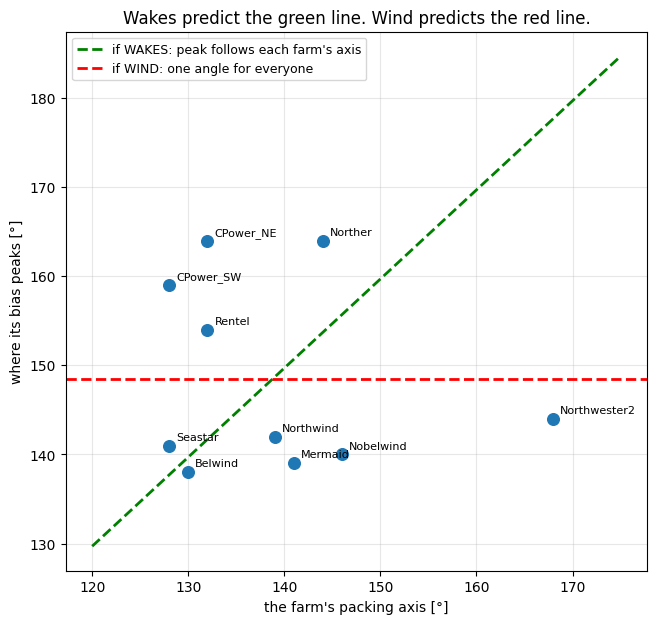

In [13]:
# ── does each farm's bias peak follow its own layout? ─────────────────────────
import numpy as np, matplotlib.pyplot as plt
# (farm, pack axis, peak direction) straight off the verify_wake_direction.py table
D = [("Belwind",130,138),("Nobelwind",146,140),("CPower_SW",128,159),("CPower_NE",132,164),
     ("Mermaid",141,139),("Seastar",128,141),("Norther",144,164),("Northwester2",168,144),
     ("Northwind",139,142),("Rentel",132,154)]
nm = [d[0] for d in D]; ax_ = np.array([d[1] for d in D]); pk = np.array([d[2] for d in D])

fig, a = plt.subplots(figsize=(7.5, 7))
a.scatter(ax_, pk, s=70, zorder=3)
for n, x, y in zip(nm, ax_, pk):
    a.annotate(n, (x, y), fontsize=8, xytext=(5, 4), textcoords="offset points")
g = np.array([120, 175])
a.plot(g, g + (pk - ax_).mean(), "g--", lw=2, label="if WAKES: peak follows each farm's axis")
a.axhline(pk.mean(), color="r", ls="--", lw=2, label="if WIND: one angle for everyone")
a.set(xlabel="the farm's packing axis [°]", ylabel="where its bias peaks [°]",
      title="Wakes predict the green line. Wind predicts the red line.")
a.legend(fontsize=9); a.grid(alpha=0.3); plt.show()
